## project objective

The objective of this project is to analyze retail sales data using Python to identify sales trends, product performance, regional performance, and generate business insights through exploratory data analysis.

## import libraries and load dataset

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv(r"C:\Users\aravi\Downloads\sales_data.csv")
print(df)

    Order_ID        Date Region   Product  Sales  Profit
0       1001  2026-01-05  North    Laptop  50000    8000
1       1002  2026-01-08  South     Mouse   1200     250
2       1003  2026-01-12   East  Keyboard   1800     400
3       1004  2026-01-15   West   Monitor  12000    2500
4       1005  2026-02-03  North     Mouse   1500     300
5       1006  2026-02-07  South    Laptop  52000    8500
6       1007  2026-02-12   East   Monitor  11000    2200
7       1008  2026-02-15   West  Keyboard   2000     500
8       1009  2026-03-04  North    Laptop  51000    8200
9       1010  2026-03-09  South   Monitor  11500    2400
10      1011  2026-03-15   East     Mouse   1300     250
11      1012  2026-03-20   West    Laptop  53000    8700


## understanging data

In [46]:

df.head()

,Order_ID,Date,Region,Product,Sales,Profit
0,1001,2026-01-05,North,Laptop,50000,8000
1,1002,2026-01-08,South,Mouse,1200,250
2,1003,2026-01-12,East,Keyboard,1800,400
3,1004,2026-01-15,West,Monitor,12000,2500
4,1005,2026-02-03,North,Mouse,1500,300


In [4]:
df.tail()

,Order_ID,Date,Region,Product,Sales,Profit
7,1008,2026-02-15,West,Keyboard,2000,500
8,1009,2026-03-04,North,Laptop,51000,8200
9,1010,2026-03-09,South,Monitor,11500,2400
10,1011,2026-03-15,East,Mouse,1300,250
11,1012,2026-03-20,West,Laptop,53000,8700


In [5]:
df.describe()

,Order_ID,Sales,Profit
count,12.000000,12.000000,12.000000
mean,1006.500000,20691.666667,3516.666667
std,3.605551,23132.285912,3671.161157
min,1001.000000,1200.000000,250.000000
25%,1003.750000,1725.000000,375.000000
50%,1006.500000,11250.000000,2300.000000
75%,1009.250000,50250.000000,8050.000000
max,1012.000000,53000.000000,8700.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Order_ID  12 non-null     int64 
 1   Date      12 non-null     object
 2   Region    12 non-null     object
 3   Product   12 non-null     object
 4   Sales     12 non-null     int64 
 5   Profit    12 non-null     int64 
dtypes: int64(3), object(3)
memory usage: 708.0+ bytes


In [7]:
df.shape

(12, 6)

## Data Cleaning

In [45]:

df.isnull().sum()

Order_ID    0
Date        0
Region      0
Product     0
Sales       0
Profit      0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

## kpi analysis

In [13]:
total_sales=df["Sales"].sum()
print(total_sales)

248300


In [14]:
total_profit=df["Profit"].sum()
print(total_profit)

42200


In [15]:
profit_margin=(total_profit/total_sales)*100
print(round((profit_margin),2))

17.0


## Exploratory Data Analysis

In [16]:
region_sales=df.groupby("Region")["Sales"].sum()
print(region_sales.sort_values(ascending=False).head(1))
   

Region
North    102500
Name: Sales, dtype: int64


In [17]:
region_sales=df.groupby("Region")["Sales"].sum()
highest_region=region_sales.idxmax()
highest_sales=region_sales.max()
print(f"Highest sales Region:{highest_region}")
print(f"sales:${highest_sales}")
   

Highest sales Region:North
sales:$102500


In [18]:
product_sales=df.groupby("Product")["Sales"].sum()
print(product_sales.sort_values(ascending=False).head(1))

Product
Laptop    206000
Name: Sales, dtype: int64


In [19]:
avg_profit=df.groupby("Region")["Profit"].mean()
print(avg_profit.sort_values(ascending=False).head(1))

Region
North    5500.0
Name: Profit, dtype: float64


In [20]:
avg_profit=df.groupby("Region")["Profit"].mean()
highest_region=avg_profit.idxmax()
highest_profit=avg_profit.max()
print(f"Highest Averege Profit Region:{highest_region}")
print(f"Average Profit:${highest_profit}")


Highest Averege Profit Region:North
Average Profit:$5500.0


In [21]:
product_profit=df.groupby("Product")["Profit"].sum()
highest_product=product_profit.idxmax()
highest_profit=product_profit.max()
print(f"Highest Total Profit Product:{highest_product}")
print(f"Total Profit:₹{highest_profit}")

Highest Total Profit Product:Laptop
Total Profit:₹33400


In [22]:
product_sales=df.groupby("Product")["Sales"].sum()
print(product_sales.sort_values(ascending=False).head(3))

Product
Laptop     206000
Monitor     34500
Mouse        4000
Name: Sales, dtype: int64


In [23]:
top3_products=df.groupby("Product")["Sales"].sum().sort_values(ascending=False).head(3)
print(top3_products)

Product
Laptop     206000
Monitor     34500
Mouse        4000
Name: Sales, dtype: int64


In [24]:
top3_regions=df.groupby("Region")[["Profit"]].sum().sort_values(by="Profit",ascending=False).head(3)
print(top3_regions)

        Profit
Region        
North    16500
West     11700
South    11150


In [25]:
region_sales_profits=df.groupby("Region")[["Sales","Profit"]].sum().sort_values(by="Sales",ascending=False)
print(region_sales_profits)

         Sales  Profit
Region                
North   102500   16500
West     67000   11700
South    64700   11150
East     14100    2850


In [26]:
region_sales_profit=df.groupby("Region")[["Sales","Profit"]].agg(["sum","mean"]).sort_values(by=("Sales","sum"),ascending=False)
print(region_sales_profit)

         Sales               Profit             
           sum          mean    sum         mean
Region                                          
North   102500  34166.666667  16500  5500.000000
West     67000  22333.333333  11700  3900.000000
South    64700  21566.666667  11150  3716.666667
East     14100   4700.000000   2850   950.000000


In [27]:
region_analysis=df.groupby("Region")[["Sales","Profit"]].sum().sort_values(by="Sales",ascending=False)
region_analysis["Profit_margin(%)"]=(region_analysis["Profit"]/region_analysis["Sales"])*100
print(region_analysis)


         Sales  Profit  Profit_margin(%)
Region                                  
North   102500   16500         16.097561
West     67000   11700         17.462687
South    64700   11150         17.233385
East     14100    2850         20.212766


In [28]:
total_sales=df["Sales"].sum()
product_analysis=df.groupby("Product")[["Sales"]].sum().sort_values(by="Sales",ascending=False)
product_analysis["Sales Contribution(%)"]=(product_analysis["Sales"]/total_sales)*100
print(product_analysis)

           Sales  Sales Contribution(%)
Product                                
Laptop    206000              82.964156
Monitor    34500              13.894482
Mouse       4000               1.610954
Keyboard    3800               1.530407


In [38]:
df["Date"]=pd.to_datetime(df["Date"])
monthly_sales=df.set_index("Date").resample("ME")[["Sales"]].sum()
monthly_sales.index=monthly_sales.index.strftime("%B")
print(monthly_sales)

           Sales
Date            
January    65000
February   66500
March     116800


In [37]:
monthly_Data=df.set_index("Date").resample("ME")[["Sales","Profit"]].sum()
monthly_Data.index=monthly_Data.index.strftime("%B")
print(monthly_Data)

           Sales  Profit
Date                    
January    65000   11150
February   66500   11500
March     116800   19550


##Visualizations

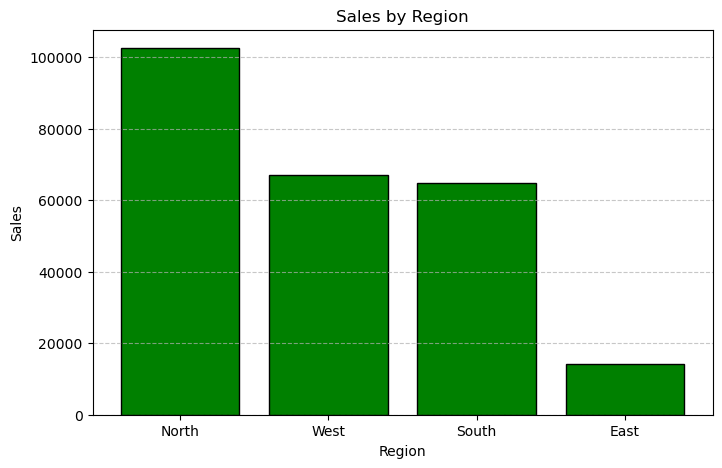

In [30]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.bar(region_analysis.index,region_analysis["Sales"],color="green",edgecolor="black")
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.grid(axis="y",linestyle="--",alpha=0.7)
plt.show()


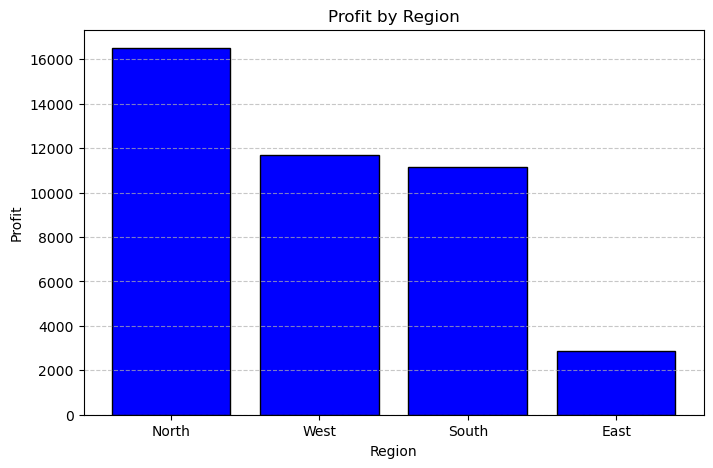

In [31]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.bar(region_analysis.index,region_analysis["Profit"],color="blue",edgecolor="black")
plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")
plt.grid(axis="y",linestyle="--",alpha=0.7)
plt.show()

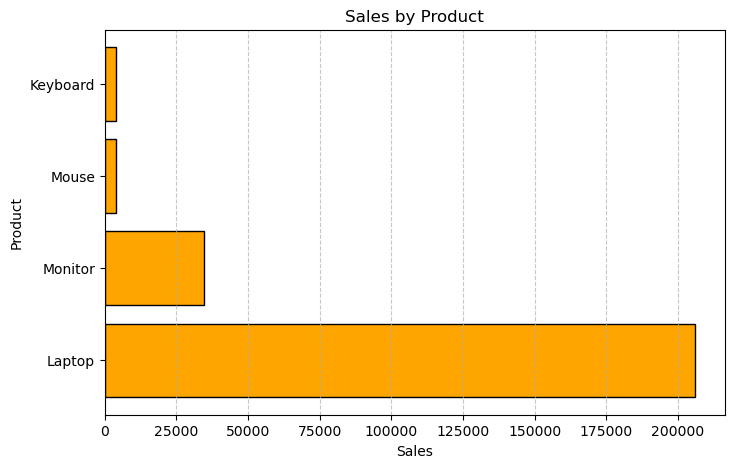

In [32]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.barh(product_analysis.index,product_analysis["Sales"],color="orange",edgecolor="black")
plt.title("Sales by Product")
plt.xlabel("Sales")
plt.ylabel("Product")
plt.grid(axis="x",linestyle="--",alpha=0.7)
plt.show()

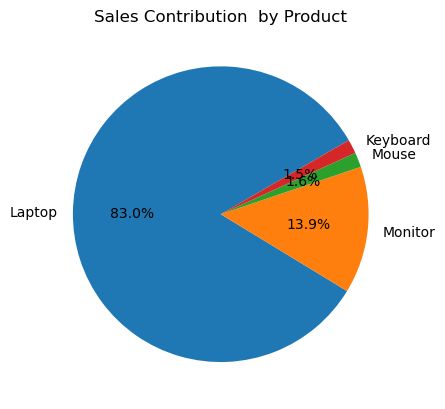

In [33]:
import matplotlib.pyplot as plt
plt.pie(product_analysis["Sales"],labels=product_analysis.index,autopct="%1.1f%%",startangle=30)
plt.title("Sales Contribution  by Product")
plt.show()

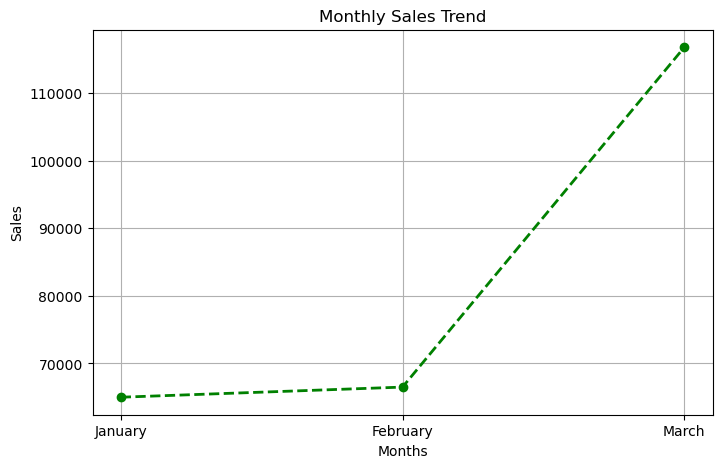

In [35]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.plot(monthly_sales.index,monthly_sales["Sales"],color="green",marker="o",linestyle="--",linewidth=2)
plt.title("Monthly Sales Trend")
plt.xlabel("Months")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

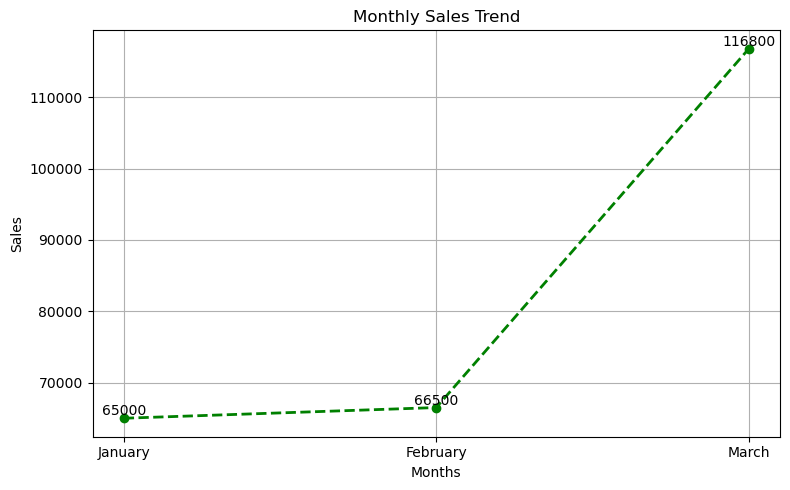

In [36]:

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    monthly_sales.index,
    monthly_sales["Sales"],
    color="green",
    marker="o",
    linestyle="--",
    linewidth=2
)

for x, y in zip(monthly_sales.index, monthly_sales["Sales"]):
    plt.text(x, y, y, ha="center", va="bottom")

plt.title("Monthly Sales Trend")
plt.xlabel("Months")
plt.ylabel("Sales")
plt.grid(True)

plt.tight_layout()
plt.show()


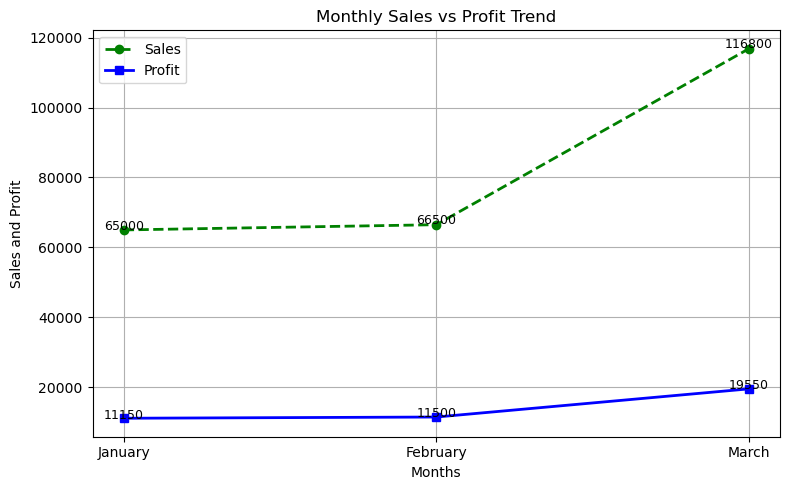

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    monthly_Data.index,
    monthly_Data["Sales"],
    color="green",
    label="Sales",
    marker="o",
    linestyle="--",
    linewidth=2
)

plt.plot(
    monthly_Data.index,
    monthly_Data["Profit"],
    color="blue",
    label="Profit",
    marker="s",
    linestyle="-",
    linewidth=2
)
for x, y in zip(monthly_Data.index, monthly_Data["Sales"]):
    plt.text(x, y+100, y, ha="center", fontsize=9)
for x, y in zip(monthly_Data.index, monthly_Data["Profit"]):
    plt.text(x, y-100, y, ha="center", fontsize=9)   

plt.title("Monthly Sales vs Profit Trend")
plt.xlabel("Months")
plt.ylabel("Sales and Profit")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

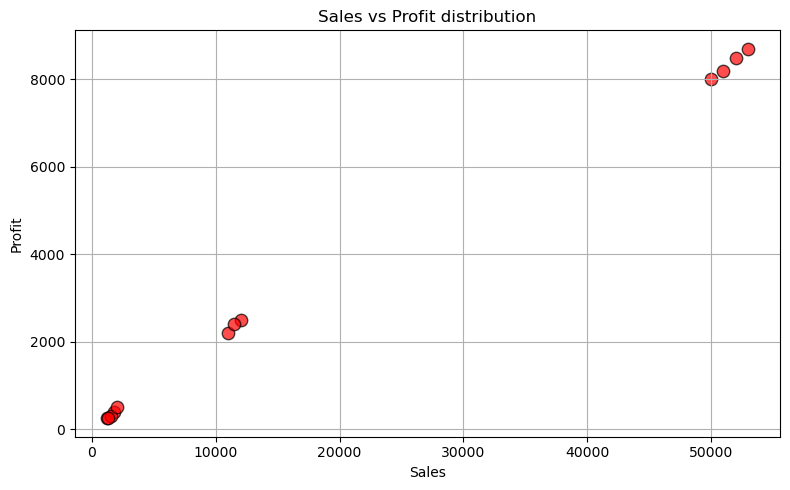

In [40]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.scatter(df["Sales"],df["Profit"],s=80,color="red",marker="o",alpha=0.7,edgecolor="black")
plt.title("Sales vs Profit distribution")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.grid(True)
plt.tight_layout()
plt.show()

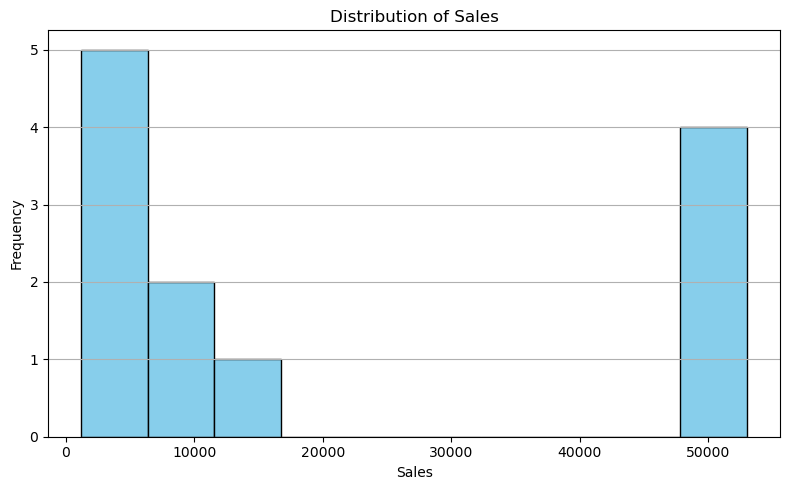

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df["Sales"], bins=10,color="skyblue",edgecolor="black")
plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

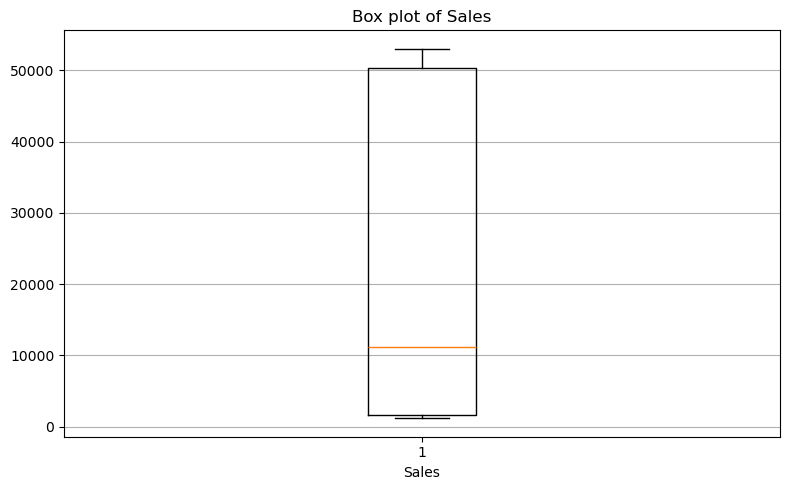

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.boxplot(df["Sales"])
plt.title("Box plot of Sales")
plt.xlabel("Sales")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

# Business Insights

### Key Findings

- South region generated the highest sales among all regions.
- North region showed strong profitability despite lower sales.
- The highest-selling products contributed significantly to overall revenue.
- Monthly sales trends highlighted periods of increased business activity.
- Scatter plot analysis indicated a positive relationship between sales and profit.
- Histogram showed that most sales fall within the medium-value range.
- Box plot analysis indicated no significant outliers in the sales data.

### Recommendations

- Increase marketing efforts in high-performing regions.
- Maintain sufficient inventory for top-selling products.
- Analyze successful sales periods to replicate business strategies.
- Focus on products that consistently generate both high sales and profit.

# Conclusion

This project demonstrates the complete data analysis workflow using Python. The dataset was cleaned, analyzed, and visualized to identify meaningful business insights. The findings can help support data-driven decision-making and improve business performance.

This project strengthened my practical skills in Python, Pandas, NumPy, Matplotlib, and Exploratory Data Analysis (EDA).

In [48]:
import os
print(os.getcwd())

C:\Users\aravi


In [49]:
import os
print(os.listdir())

['.anaconda', '.antigravity', '.conda', '.continuum', '.copilot', '.gemini', '.ipynb_checkpoints', '.ipython', '.jupyter', '.matplotlib', '.streamlit', '.vscode', '.vscode-shared', 'anaconda3', 'AppData', 'Application Data', 'Contacts', 'Cookies', 'Documents', 'Downloads', 'Favorites', 'Links', 'Local Settings', 'Microsoft', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{54cded87-63c2-11f0-9fda-b8f77509fe1f}.TxR.0.regtrans-ms', 'NTUSER.DAT{54cded87-63c2-11f0-9fda-b8f77509fe1f}.TxR.1.regtrans-ms', 'NTUSER.DAT{54cded87-63c2-11f0-9fda-b8f77509fe1f}.TxR.2.regtrans-ms', 'NTUSER.DAT{54cded87-63c2-11f0-9fda-b8f77509fe1f}.TxR.blf', 'NTUSER.DAT{54cded88-63c2-11f0-9fda-b8f77509fe1f}.TM.blf', 'NTUSER.DAT{54cded88-63c2-11f0-9fda-b8f77509fe1f}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{54cded88-63c2-11f0-9fda-b8f77509fe1f}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'OneDrive', 'package-lock.json', 'PrintHood', 'Rec